# Thesis Figures
Generates all thesis figures as vector PDFs from stored artifacts. **No API calls, no retraining.**
Output: `thesis-docs/thesis-paper/figures/*.pdf`

In [1]:
import json, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
RES = ROOT / 'experiments' / 'results'
PROC = ROOT / 'data' / 'processed'
FIG = ROOT / 'thesis-docs' / 'thesis-paper' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

def pair_sim(left, right):
    strip = lambda t: re.sub(r'COL \S+ VAL\s*', ' ', str(t)).lower().split()
    a, b = set(strip(left)), set(strip(right))
    return len(a & b) / len(a | b) if a | b else 0.0

def load_pairs(path):
    out = []
    for line in open(path, encoding='utf-8'):
        p = line.rstrip('\n').split('\t')
        if len(p) == 3:
            out.append((p[0], p[1], int(p[2])))
    return out
import glob, statistics
def run_f1(run, ds):
    """3-seed mean/std F1 from per-seed result files (robust to stale aggregate files)."""
    vals = [json.load(open(f))['metrics']['f1'] for f in sorted(glob.glob(str(RES / f'{run}_s*_{ds}_test.json')))]
    if not vals:
        return None, None
    return statistics.mean(vals), (statistics.stdev(vals) if len(vals) > 1 else 0.0)

print('setup ok, figures ->', FIG)

setup ok, figures -> /Users/abd/Developer/thesis-project/thesis-docs/thesis-paper/figures


## Figure 1 — Main results: 3-seed F1 with error bars (both datasets)

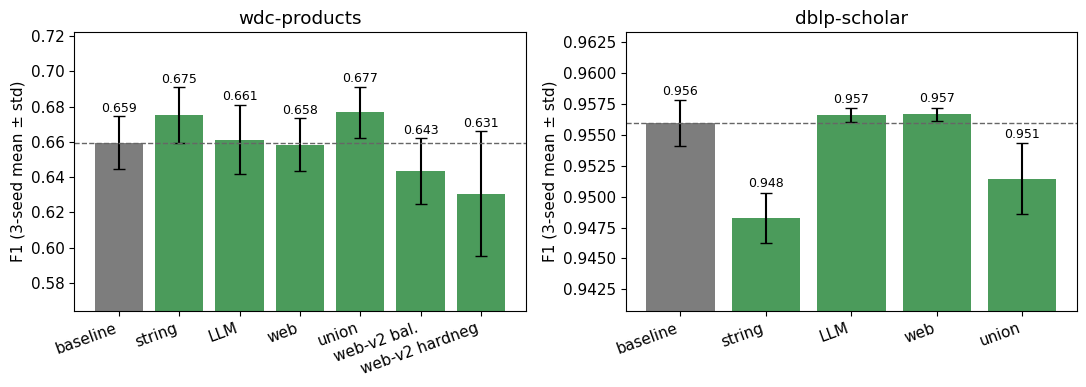

In [2]:
ORDER = {'wdc-products': ['baseline_cw', 'string_aug_cw', 'llm_aug_cw', 'web_aug_cw', 'union_all_cw', 'web_v2_bal_cw', 'web_v2_hn_cw'],
         'dblp-scholar': ['baseline', 'string_aug', 'llm_aug', 'web_aug', 'union_all']}
LABEL = {'baseline_cw': 'baseline', 'string_aug_cw': 'string', 'llm_aug_cw': 'LLM', 'web_aug_cw': 'web',
         'web_v2_bal_cw': 'web-v2 bal.', 'web_v2_hn_cw': 'web-v2 hardneg', 'union_all_cw': 'union', 'union_all': 'union',
         'baseline': 'baseline', 'string_aug': 'string', 'llm_aug': 'LLM', 'web_aug': 'web'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ds in zip(axes, ['wdc-products', 'dblp-scholar']):
    stats = {r: run_f1(r, ds) for r in ORDER[ds]}
    runs = [r for r in ORDER[ds] if stats[r][0] is not None]
    means = [stats[r][0] for r in runs]
    stds = [stats[r][1] for r in runs]
    colors = ['#666666'] + ['#2b8a3e'] * (len(runs) - 1)
    x = np.arange(len(runs))
    ax.bar(x, means, yerr=stds, capsize=4, color=colors, alpha=0.85)
    ax.axhline(means[0], color='#666666', ls='--', lw=1)
    ax.set_xticks(x); ax.set_xticklabels([LABEL[r] for r in runs], rotation=20, ha='right')
    ax.set_title(ds); ax.set_ylabel('F1 (3-seed mean ± std)')
    lo = min(m - s for m, s in zip(means, stds))
    hi = max(m + s for m, s in zip(means, stds))
    pad = (hi - lo) * 0.3 + 0.002
    ax.set_ylim(lo - pad, hi + pad)
    for xi, (m, s) in enumerate(zip(means, stds)):
        ax.text(xi, m + s + pad * 0.08, f'{m:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG / 'results_f1_bars.pdf', bbox_inches='tight')
plt.show()

## Figure 2 — Layer 2: similarity distributions per training set, split by label

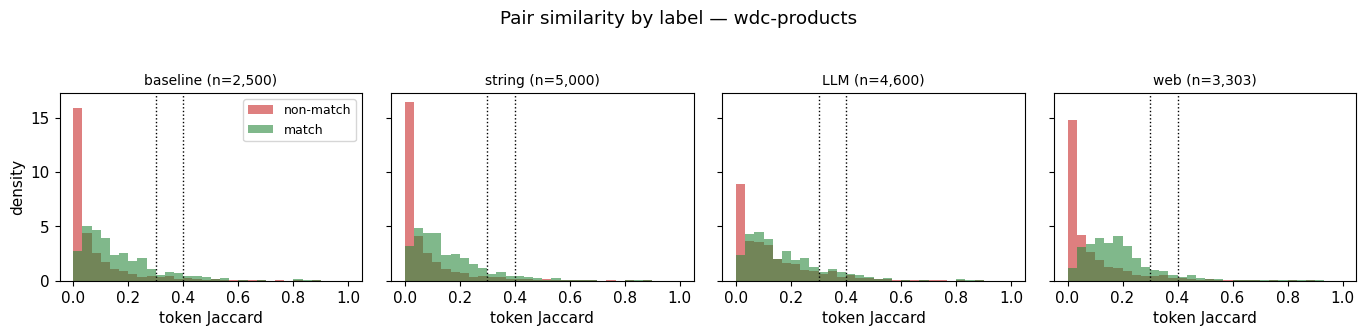

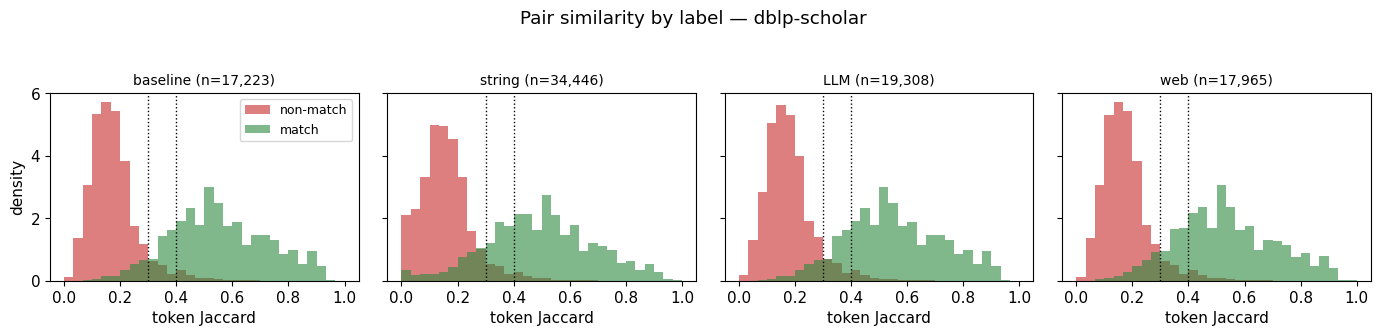

In [3]:
FILES = {'baseline': 'train.txt', 'string': 'train_aug_string.txt', 'LLM': 'train_aug_llm.txt', 'web': 'train_aug_web.txt'}
for ds in ['wdc-products', 'dblp-scholar']:
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
    for ax, (name, fn) in zip(axes, FILES.items()):
        pairs = load_pairs(PROC / ds / fn)
        sims = np.array([pair_sim(l, r) for l, r, _ in pairs])
        labs = np.array([y for _, _, y in pairs])
        bins = np.linspace(0, 1, 31)
        ax.hist(sims[labs == 0], bins=bins, alpha=0.6, label='non-match', color='#c92a2a', density=True)
        ax.hist(sims[labs == 1], bins=bins, alpha=0.6, label='match', color='#2b8a3e', density=True)
        ax.axvline(0.3, color='k', ls=':', lw=1); ax.axvline(0.4, color='k', ls=':', lw=1)
        ax.set_title(f'{name} (n={len(pairs):,})', fontsize=10)
        ax.set_xlabel('token Jaccard')
    axes[0].set_ylabel('density'); axes[0].legend(fontsize=9)
    fig.suptitle(f'Pair similarity by label — {ds}', y=1.04)
    plt.tight_layout()
    plt.savefig(FIG / f'layer2_sim_hist_{ds}.pdf', bbox_inches='tight')
    plt.show()

## Figure 3 — Layer 3: error-class breakdown per run (from seed-averaged predictions)

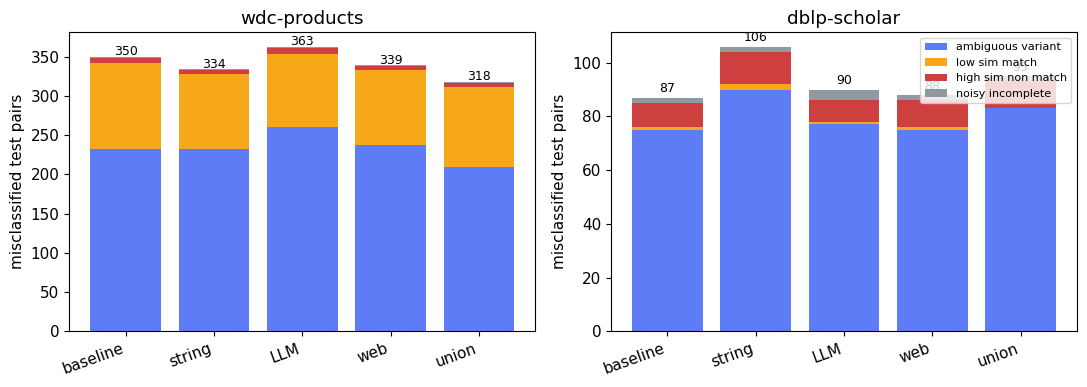

In [4]:
def classify(rec):
    sim = pair_sim(rec['left'], rec['right'])
    ntoks = min(len(re.sub(r'COL \S+ VAL\s*', ' ', rec['left']).split()), len(re.sub(r'COL \S+ VAL\s*', ' ', rec['right']).split()))
    if ntoks < 6: return 'noisy_incomplete'
    if rec['pred_label'] == 1 and rec['true_label'] == 0 and sim > 0.5: return 'high_sim_non_match'
    if rec['pred_label'] == 0 and rec['true_label'] == 1 and sim < 0.2: return 'low_sim_match'
    return 'ambiguous_variant'

CLASSES = ['ambiguous_variant', 'low_sim_match', 'high_sim_non_match', 'noisy_incomplete']
CCOL = {'ambiguous_variant': '#4c6ef5', 'low_sim_match': '#f59f00', 'high_sim_non_match': '#c92a2a', 'noisy_incomplete': '#868e96'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ds in zip(axes, ['wdc-products', 'dblp-scholar']):
    runs = [r for r in ORDER[ds] if not r.startswith('web_v2')]
    counts = {}
    for run in runs:
        f = RES / f'{run}_seedmean_{ds}_test_preds.jsonl'
        errs = [json.loads(l) for l in open(f)]
        errs = [e for e in errs if e['pred_label'] != e['true_label']]
        c = {k: 0 for k in CLASSES}
        for e in errs: c[classify(e)] += 1
        counts[run] = c
    x = np.arange(len(runs)); bottom = np.zeros(len(runs))
    for cls in CLASSES:
        vals = np.array([counts[r][cls] for r in runs])
        ax.bar(x, vals, bottom=bottom, label=cls.replace('_', ' '), color=CCOL[cls], alpha=0.9)
        bottom += vals
    for xi, r in enumerate(runs):
        ax.text(xi, bottom[xi] + 2, str(int(bottom[xi])), ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels([LABEL[r] for r in runs], rotation=20, ha='right')
    ax.set_title(ds); ax.set_ylabel('misclassified test pairs')
axes[1].legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(FIG / 'layer3_error_classes.pdf', bbox_inches='tight')
plt.show()

## Figure 4 — AL positive rate per iteration, both datasets (full 1–20 range)

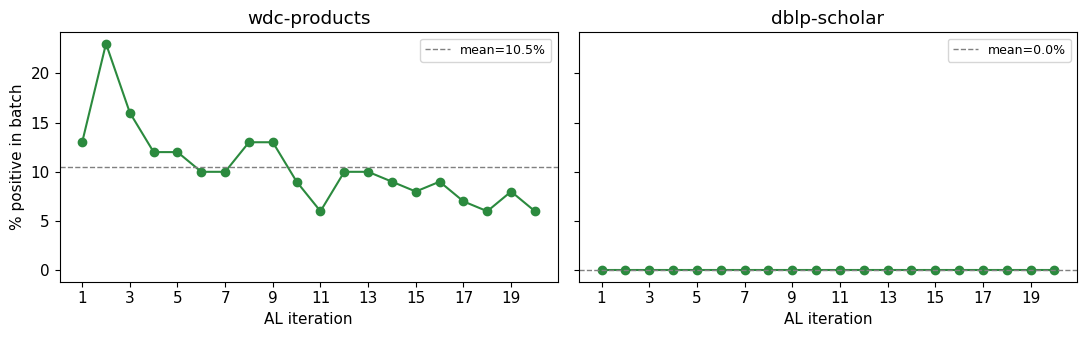

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, ds in zip(axes, ['wdc-products', 'dblp-scholar']):
    recs = [json.loads(l) for l in open(PROC / ds / 'al_labeled.jsonl')]
    iters = {}
    for i, r in enumerate(recs):
        it = i // 100 + 1  # 100 labels per iteration, in labeling order
        iters.setdefault(it, []).append(r['label'])
    ks = sorted(iters)
    rates = [100 * sum(iters[k]) / len(iters[k]) for k in ks]
    mean = 100 * sum(r['label'] for r in recs) / len(recs)
    ax.plot(ks, rates, 'o-', color='#2b8a3e')
    ax.axhline(mean, color='gray', ls='--', lw=1, label=f'mean={mean:.1f}%')
    ax.set_title(ds); ax.set_xlabel('AL iteration'); ax.legend(fontsize=9)
    ax.set_xticks(ks[::2])
axes[0].set_ylabel('% positive in batch')
plt.tight_layout()
plt.savefig(FIG / 'al_positive_rate.pdf', bbox_inches='tight')
plt.show()

## Figure 5 — Cross-study comparison: GT labels vs. LLM-teacher labels (DistillER-style)
Mirrors DistillER Table 8 as a grouped-bar figure, with Aaron's and our numbers added.
Published numbers are hardcoded from the papers (sources in code comments); ours from `seed_aggregate_*.json`.

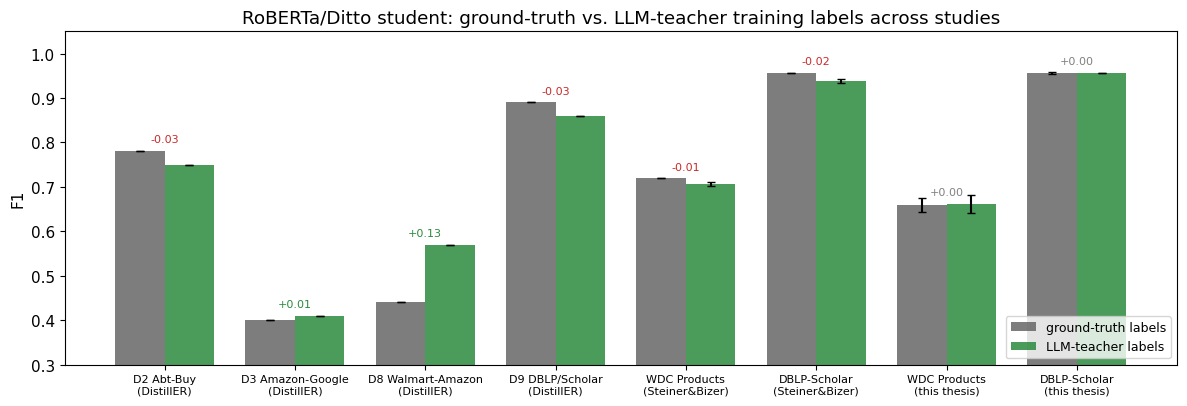

In [6]:
# Sources: DistillER (Zeakis et al., arXiv 2602.05452) Table 8, RoBERTa student, Qwen-2.5:32b teacher;
# Aaron (Steiner & Bizer, arXiv 2606.28823) Table 1, Ditto student, GPT-5.2 teacher, AL(ML) variant.
# 'GT' = student trained on ground-truth labels; 'LLM' = student trained on LLM-teacher labels
# (for this thesis: GT base + LLM-labeled additions, i.e. the expansion setting).
w_base = run_f1('baseline_cw', 'wdc-products'); w_llm = run_f1('llm_aug_cw', 'wdc-products')
d_base = run_f1('baseline', 'dblp-scholar');    d_llm = run_f1('llm_aug', 'dblp-scholar')
entries = [
    ('D2 Abt-Buy\n(DistillER)',        0.78, 0.75, None, None),
    ('D3 Amazon-Google\n(DistillER)',  0.40, 0.41, None, None),
    ('D8 Walmart-Amazon\n(DistillER)', 0.44, 0.57, None, None),
    ('D9 DBLP/Scholar\n(DistillER)',   0.89, 0.86, None, None),
    ('WDC Products\n(Steiner&Bizer)',  0.719, 0.707, None, 0.004),
    ('DBLP-Scholar\n(Steiner&Bizer)',  0.956, 0.938, None, 0.004),
    ('WDC Products\n(this thesis)',    w_base[0], w_llm[0], w_base[1], w_llm[1]),
    ('DBLP-Scholar\n(this thesis)',    d_base[0], d_llm[0], d_base[1], d_llm[1]),
]
x = np.arange(len(entries)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 4.2))
gt  = [e[1] for e in entries]; llm = [e[2] for e in entries]
gte = [e[3] or 0 for e in entries]; lle = [e[4] or 0 for e in entries]
ax.bar(x - w/2, gt,  w, yerr=gte, capsize=3, label='ground-truth labels', color='#666666', alpha=0.85)
ax.bar(x + w/2, llm, w, yerr=lle, capsize=3, label='LLM-teacher labels',  color='#2b8a3e', alpha=0.85)
for xi, (g, l) in enumerate(zip(gt, llm)):
    d = l - g
    ax.text(xi, max(g, l) + 0.02, f'{d:+.2f}', ha='center', fontsize=8,
            color='#2b8a3e' if d > 0.005 else ('#c92a2a' if d < -0.005 else 'gray'))
ax.set_xticks(x); ax.set_xticklabels([e[0] for e in entries], fontsize=8)
ax.set_ylabel('F1'); ax.set_ylim(0.3, 1.05); ax.legend(fontsize=9, loc='lower right')
ax.set_title('RoBERTa/Ditto student: ground-truth vs. LLM-teacher training labels across studies')
plt.tight_layout(); plt.savefig(FIG / 'comparison_gt_vs_llm.pdf', bbox_inches='tight'); plt.show()

## Figure 6 — Budget curve: F1 vs. training set size (Aaron Fig.-4 style)
Our runs are plotted exactly (size of the training file vs. 3-seed F1).
Aaron's WDC curve anchors are **approximate, read from his Figure 4** — replace `AARON_CURVE` with exact digitized values before submission.
If union / low-resource results exist, they are included automatically.

  [skip] sub50_cw (not run yet or file missing)
  [skip] sub50_llm_cw (not run yet or file missing)
  [skip] sub25_cw (not run yet or file missing)
  [skip] sub25_llm_cw (not run yet or file missing)


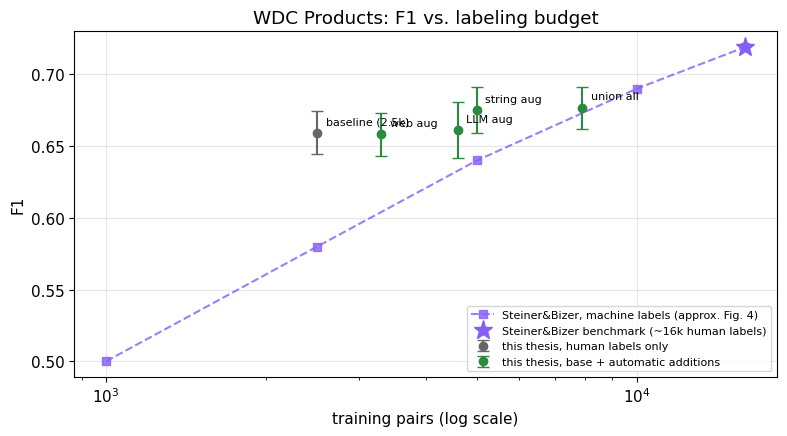

In [7]:
# --- our WDC points (per-seed files via run_f1 from the setup cell) ---
def f1_of_run(run, ds='wdc-products'):
    return run_f1(run, ds)

def n_pairs(fn):
    p = PROC / 'wdc-products' / fn
    return sum(1 for _ in open(p)) if p.exists() else None

POINTS = [  # (run, train file, label)
    ('baseline_cw',   'train.txt',               'baseline (2.5k)'),
    ('string_aug_cw', 'train_aug_string.txt',    'string aug'),
    ('llm_aug_cw',    'train_aug_llm.txt',       'LLM aug'),
    ('web_aug_cw',    'train_aug_web.txt',       'web aug'),
    ('union_all_cw',  'train_aug_union_all.txt', 'union all'),
    ('sub50_cw',      'train_sub50.txt',         'base 50%'),
    ('sub50_llm_cw',  'train_sub50_llm.txt',     'base 50% + LLM'),
    ('sub25_cw',      'train_sub25.txt',         'base 25%'),
    ('sub25_llm_cw',  'train_sub25_llm.txt',     'base 25% + LLM'),
]

# --- Aaron's WDC anchors (Steiner & Bizer Fig. 4, Ditto student) ---
# APPROXIMATE values read off the figure; replace with exact digitized points.
AARON_CURVE = [(1000, 0.50), (2500, 0.58), (5000, 0.64), (10000, 0.69), (16000, 0.719)]
AARON_BENCH = (16000, 0.719)  # large-split human-label benchmark, Table 1

fig, ax = plt.subplots(figsize=(8, 4.5))
xs = [p[0] for p in AARON_CURVE]; ys = [p[1] for p in AARON_CURVE]
ax.plot(xs, ys, 's--', color='#845ef7', alpha=0.8, label='Steiner&Bizer, machine labels (approx. Fig. 4)')
ax.plot(*AARON_BENCH, marker='*', ms=14, color='#845ef7', ls='none', label='Steiner&Bizer benchmark (~16k human labels)')
shown = set()
for run, fn, lab in POINTS:
    m, s = f1_of_run(run)
    n = n_pairs(fn)
    if m is None or n is None:
        print(f'  [skip] {run} (not run yet or file missing)'); continue
    is_base = ('llm' not in run and 'aug' not in run and 'union' not in run)
    col = '#666666' if is_base else '#2b8a3e'
    key = 'this thesis, human labels only' if is_base else 'this thesis, base + automatic additions'
    ax.errorbar(n, m, yerr=s, fmt='o', color=col, capsize=4, label=key if key not in shown else None)
    shown.add(key)
    ax.annotate(lab, (n, m), textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.set_xscale('log'); ax.set_xlabel('training pairs (log scale)'); ax.set_ylabel('F1')
ax.set_title('WDC Products: F1 vs. labeling budget')
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'budget_curve_wdc.pdf', bbox_inches='tight'); plt.show()

## Figure 7 — Low-resource ablation (auto-generates once sub25/sub50 runs exist)
Tests the DistillER-D8 / Aaron-Fig.-4 hypothesis: does the LLM-augmentation benefit grow as the base shrinks?

In [8]:
pairs = [('sub25_cw', 'sub25_llm_cw', '25% base\n(~625)'),
         ('sub50_cw', 'sub50_llm_cw', '50% base\n(~1250)'),
         ('baseline_cw', 'llm_aug_cw', '100% base\n(2500)')]
rows = []
for b, t, lab in pairs:
    bm, bs = f1_of_run(b); tm, ts = f1_of_run(t)
    if bm is not None and tm is not None:
        rows.append((lab, bm, bs, tm, ts))
if len(rows) < 2:
    print('Low-resource runs not available yet — run the sub25/sub50 configs first; this cell will then produce the figure.')
else:
    x = np.arange(len(rows)); w = 0.38
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - w/2, [r[1] for r in rows], w, yerr=[r[2] for r in rows], capsize=4, label='base only', color='#666666', alpha=0.85)
    ax.bar(x + w/2, [r[3] for r in rows], w, yerr=[r[4] for r in rows], capsize=4, label='base + LLM additions', color='#2b8a3e', alpha=0.85)
    for xi, r in enumerate(rows):
        ax.text(xi, max(r[1], r[3]) + 0.015, f'{r[3]-r[1]:+.3f}', ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
    ax.set_ylabel('F1 (3-seed mean ± std)'); ax.legend(fontsize=9)
    ax.set_title('WDC Products: does LLM augmentation help more when the base is smaller?')
    plt.tight_layout(); plt.savefig(FIG / 'low_resource_ablation.pdf', bbox_inches='tight'); plt.show()

Low-resource runs not available yet — run the sub25/sub50 configs first; this cell will then produce the figure.


## LaTeX snippets
```latex
\begin{figure}[tb]\centering
  \includegraphics[width=\textwidth]{figures/results_f1_bars.pdf}
  \caption{Test F1 of all strategies (3-seed mean $\pm$ std). Dashed line: baseline mean.}
  \label{fig:results}
\end{figure}
```
Same pattern for `layer2_sim_hist_*.pdf` (Sec. 6.5), `layer3_error_classes.pdf` (Sec. 6.7), `al_positive_rate.pdf` (Sec. 4.4/6.4 — the positive-scarcity figure). New comparison figures: `comparison_gt_vs_llm.pdf` (Sec. 8.2/8.4), `budget_curve_wdc.pdf` (Sec. 8.3.4), `low_resource_ablation.pdf` (Sec. 7.4). Add `figures/` next to `thesis.tex`.